In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV

In [37]:
df = pd.read_csv('./data_public.csv')
df.head()

,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,Class
0,231.420023,-12.210984,217.624839,-15.611916,140.047185,76.904999,131.591871,198.160805,82.873279,127.350084,224.592926,-5.992983,-14.689648,143.072058,153.439659,2
1,-38.019270,-14.195695,9.583547,22.293822,-25.578283,-18.373955,-0.094457,-33.711852,-8.356041,23.792402,4.199023,2.809159,-59.330681,-11.685950,1.317104,3
2,-39.197085,-20.418850,21.023083,19.790280,-25.902587,-19.189004,-2.953836,-25.299219,-6.612401,26.285392,5.911292,6.191587,-56.924996,-4.675187,-1.027830,2
3,221.630408,-5.785352,216.725322,-9.900781,126.795177,85.122288,108.857593,197.640135,82.560019,157.105143,212.989231,-3.621070,-15.469156,135.265859,149.212489,2
4,228.558412,-12.447710,204.637218,-13.277704,138.930529,91.101870,115.598954,209.300011,89.961688,130.299732,201.795100,-1.573922,-15.128603,148.368622,147.492663,3


In [38]:
labels = df.columns.tolist()[:-1]
X = pd.DataFrame(data=df.drop('Class', axis=1),
columns=labels)
y = pd.DataFrame(data=df['Class'],
columns=['Class'])
X_train, X_test, y_train, y_test = train_test_split(X,
y,
test_size=0.3)
training_data = pd.concat([X_train,
y_train],
axis=1)
training_data.head()

,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,Class
376018,-26.969499,-20.846455,12.311930,16.150187,-23.614847,-32.926039,1.933121,-20.682814,-7.477394,28.783059,-3.748233,0.371951,-53.297947,-6.946601,0.284644,1
848336,-62.272013,-52.468189,-47.007783,-99.574060,-12.381852,-127.374343,-53.387733,-12.223766,56.964652,-89.904372,53.227290,-38.163786,-53.000596,34.536571,54.950605,2
620617,243.321121,-14.121769,223.873615,-13.106331,129.990949,85.242442,127.809707,205.657512,77.227953,138.826249,202.328726,-7.825139,-7.866747,145.803376,149.450295,3
567479,-31.917129,-15.141017,8.668098,19.753581,-24.328461,-27.548508,-0.158687,-20.901071,-7.187142,21.156300,6.621384,3.927719,-56.776924,-7.774762,-10.247546,3
1141712,-39.922107,-18.220563,10.028576,13.386369,-18.974124,-28.681862,-0.120660,-23.971737,-6.774577,20.701464,-1.425539,7.558367,-55.205704,-6.495735,3.157440,2


In [39]:
print(df.isnull().sum())  
# 补充缺失项
num_cols = df.select_dtypes(include='number').columns
imputer_knn = KNNImputer(n_neighbors=5)
df[num_cols] = imputer_knn.fit_transform(df[num_cols])

A        0
B        0
C        0
D        0
E        0
F        0
G        0
H        0
I        0
J        0
K        0
L        0
M        0
N        0
O        0
Class    0
dtype: int64


In [40]:

# --- 互信息筛选：剔除 MI=0 特征 ---
mi = mutual_info_classif(X, y.values.ravel())
mi_scores = pd.DataFrame({
    'Feature': X.columns, 
    'Mutual Info': mi
}).sort_values('Mutual Info', ascending=False)
zero_mi_cols = mi_scores[mi_scores['Mutual Info'] == 0]['Feature'].tolist()
X = X.drop(columns=zero_mi_cols)
df = df.drop(columns=zero_mi_cols)
print(f'MI=0 剔除: {zero_mi_cols if zero_mi_cols else "无"}, 剩余 {X.shape[1]} 特征')

# --- 共线性筛选：剔除相关系数 > 0.98 的冗余特征 ---
corr = X.corr().abs()
high_corr_pairs = []
drop_collinear = set()
for i in range(len(corr.columns)):
    for j in range(i):
        if corr.iloc[i, j] > 0.98:
            col_i, col_j = corr.columns[i], corr.columns[j]
            corr_i = abs(X[col_i].corr(y['Class']))
            corr_j = abs(X[col_j].corr(y['Class']))
            drop = col_j if corr_i >= corr_j else col_i
            drop_collinear.add(drop)
            high_corr_pairs.append(f'{col_i}↔{col_j} r={corr.iloc[i,j]:.3f} → 删 {drop}')

print(f'\n共线性 >0.98 的特征对:')
for p in high_corr_pairs:
    print(f'  {p}')

if drop_collinear:
    X = X.drop(columns=list(drop_collinear))
    df = df.drop(columns=list(drop_collinear))
print(f'\n共线性剔除: {list(drop_collinear) if drop_collinear else "无"}, 剩余 {X.shape[1]} 特征')

# --- 重新划分 ---
labels = df.columns.tolist()[:-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=91)
print(f'最终特征 ({X.shape[1]} 个): {list(X.columns)}')

MI=0 剔除: ['B', 'G', 'F', 'E', 'C', 'A', 'H', 'M', 'O'], 剩余 6 特征

共线性 >0.98 的特征对:
  N↔K r=0.992 → 删 K

共线性剔除: ['K'], 剩余 5 特征
最终特征 (5 个): ['D', 'I', 'J', 'L', 'N']


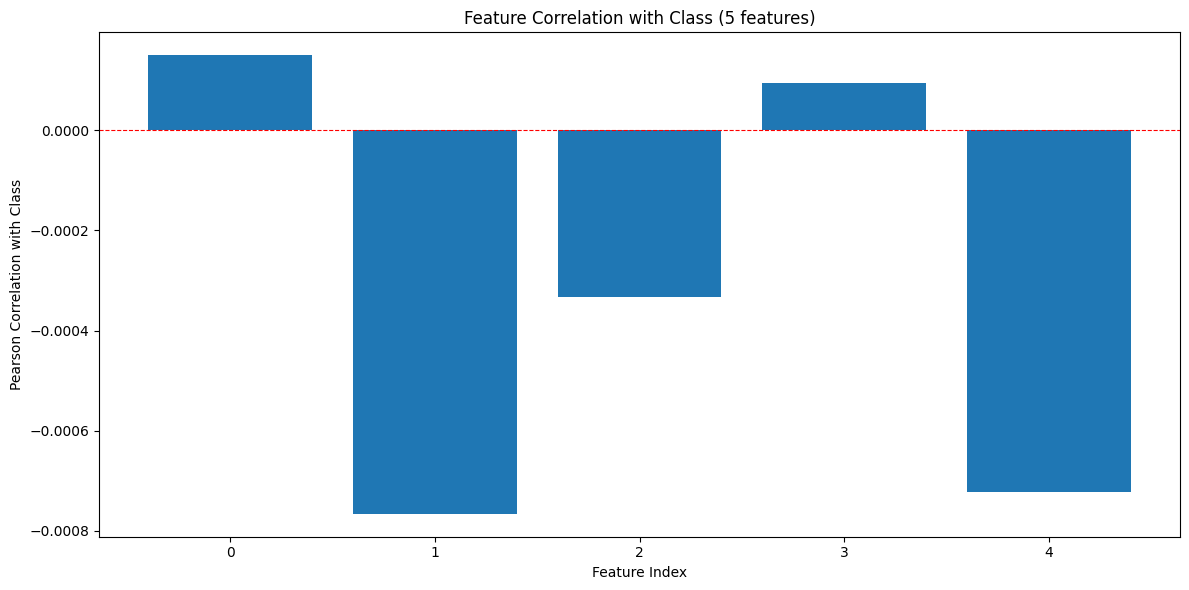

In [41]:

# Calculate correlation between each feature and Class (Pearson correlation coefficient)
correlations = X.corrwith(y['Class'])

# Plot correlation bar chart
plt.figure(figsize=(12, 6))
plt.bar(range(len(correlations)), correlations.values)
plt.xlabel('Feature Index')
plt.ylabel('Pearson Correlation with Class')
plt.title(f'Feature Correlation with Class ({len(correlations)} features)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


## Build Pipeline (Imputer → StandardScaler → Classifier)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# ============================================================
# PCA 降维 → 逻辑回归 vs 随机森林对比
# ============================================================

# Step 1: Impute → Standardize → PCA（一次降维，保留 90% 方差）
pca_pipe = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90))
])
X_train_reduced = pca_pipe.fit_transform(X_train)
X_test_reduced  = pca_pipe.transform(X_test)

n_orig = X_train.shape[1]
n_pca  = X_train_reduced.shape[1]
print(f'PCA 降维: {n_orig} 维 → {n_pca} 维（保留 90% 方差）\n')

# Step 2: 两个模型分别 GridSearchCV 调参
results = {}

# --- 逻辑回归 ---
lr = LogisticRegression(max_iter=1000, random_state=91)
lr_param = {'C': [0.01, 0.1, 1, 10, 100]}
lr_grid = GridSearchCV(lr, lr_param, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_reduced, y_train.values.ravel())
results['LogisticRegression'] = {
    'best_params': lr_grid.best_params_,
    'cv_mean': lr_grid.best_score_,
    'train': lr_grid.score(X_train_reduced, y_train.values.ravel()),
    'test':  lr_grid.score(X_test_reduced, y_test.values.ravel()),
}

# --- 随机森林 ---
rf = RandomForestClassifier(class_weight='balanced', random_state=91, n_jobs=-1)
rf_param = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4, 5],
}
rf_grid = GridSearchCV(rf, rf_param, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_reduced, y_train.values.ravel())
results['RandomForest'] = {
    'best_params': rf_grid.best_params_,
    'cv_mean': rf_grid.best_score_,
    'train': rf_grid.score(X_train_reduced, y_train.values.ravel()),
    'test':  rf_grid.score(X_test_reduced, y_test.values.ravel()),
}

# Step 3: 对比输出
print(f'{"模型":<20s} {"最优参数":<35s} {"CV均值":>8s} {"训练集":>8s} {"测试集":>8s}')
print('-' * 85)
for name, r in results.items():
    params_str = str(r['best_params']).replace('{','').replace('}','').replace("'","")
    print(f'{name:<20s} {params_str:<35s} {r["cv_mean"]:>8.4f} {r["train"]:>8.4f} {r["test"]:>8.4f}')

PCA 降维: 5 维 → 2 维（保留 98% 方差）

模型                   最优参数                                    CV均值      训练集      测试集
-------------------------------------------------------------------------------------
LogisticRegression   C: 0.01                               0.4989   0.4989   0.5005
RandomForest         max_depth: 5, n_estimators: 50        0.3180   0.2879   0.2830
